# Week 6 - Linear Regression - solution

Learning contents:

1. Linear models
    - Polynomial function
    - Radial basis function
    - Sigmoidal basis function
    - Optimization of Error function
    - Test models
2. Bayesian Linear Regression
    - Generate data
    - Fit the data
    - Predictive distribution

## Dependencies

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import exp
from scipy.stats import multivariate_normal

import seaborn as sns; sns.set(); sns.set_palette('bright')

## Generate Data

The following functions generate training and test data corresponding to a sinusoid function. The data corresponds to a regression problem where individual input `x` and output `y` are both scalars

In [8]:
def target_func(x): return np.sin(2*np.pi*x)

def generate_data(size):
    rng = np.random.RandomState(26052605)
    x_train = rng.uniform(0., 1., size)
    y_train = target_func(x_train) + rng.normal(scale=0.1, size=size)
    x_test = np.linspace(0., 1., 100)
    y_test = target_func(x_test)

    return x_train, y_train, x_test, y_test

x_train, y_train, x_test, y_test = generate_data(10)

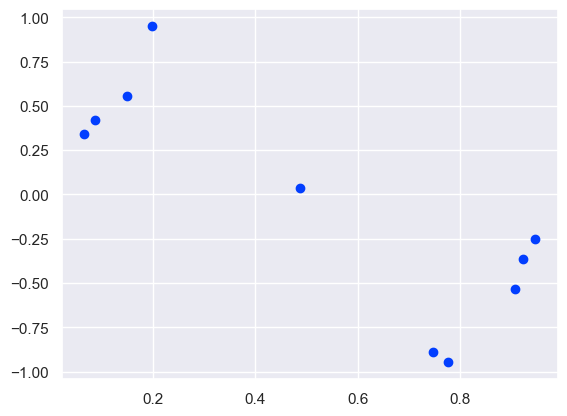

In [9]:
plt.scatter(x_train, y_train)

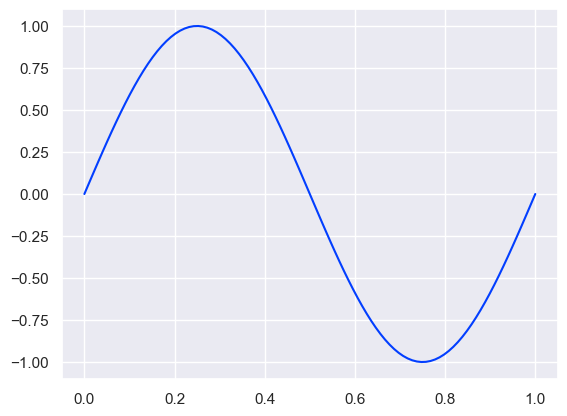

In [10]:
plt.plot(x_test, y_test, '-')

## 1) Linear models

Write down the function named `linear` that takes data point `x` (scalar), a `basis` function, and `weights` (list|ndarray (M+1)x1) and returns the output of linear basis function model (2nd equation in slide 5 of lecture 11, eq (3.3) in text book)

The `basis` function (Phi(x)) that goes as input to `linear` will be defined later but it takes `x` (scalar) and `i` (index) and returns `Phi_i(x)` (which is a scalar).

In [11]:
def linear(x, basis, weights):
   result = 0

   for i, w in enumerate(weights):
       result += w * (1 if i == 0 else basis(x, i))

   return result

### 1.1) Polynomial basis function

In `create_polynomial` below, write the code of `polynomial` function that takes data point `x` (scalar) and `i` (index) and returns the i-th value (scalar) of a polynomial basis function Phi_i(x) (see equation in slide 7 of lecture 11).

In [12]:
def create_polynomial():
    def polynomial(x, i):
        return x ** i

    return polynomial

Plot the different polynomial basis functions for input `x` ranging from -1 to 1

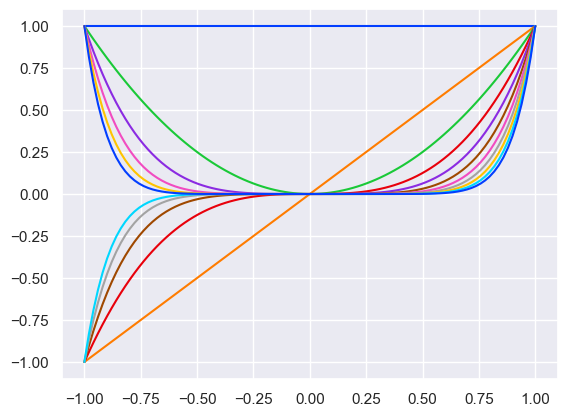

In [13]:
x = np.linspace(-1, 1, 100)
n = 11

polynomial = create_polynomial()

for i in range(n):
    y = list(map(lambda x: polynomial(x, i), x))
    plt.plot(x, y, '-')

### 1.2) Radial basis function

In `create_radial` function below, write the code of `radial` function that takes data point `x` (scalar) and `i` (index) and returns the i-th value (scalar) of a radial basis function Phi_i(x) (see equation in slide 8 of lecture 11). The outer `create_radial` function takes mean and variance as input which are used by the `radial` function.

In [21]:
def create_radial(means, variance):
    def radial(x, i):
        return exp(-0.5 * (x - means[i]) ** 2 / variance)

    return radial



Plot the different radial basis functions for input `x` ranging from -1 to 1

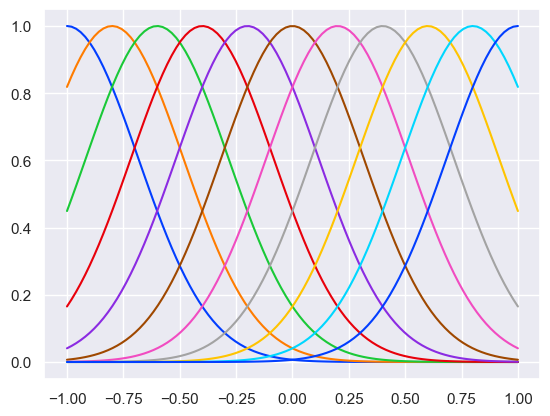

In [22]:
x = np.linspace(-1, 1, 100)
n = 11

radial = create_radial(np.linspace(-1, 1, 11), 0.1)

for i in range(n):
    y = list(map(lambda x: radial(x, i), x))
    plt.plot(x, y, '-')



### 1.3) Sigmoidal basis function

In `create_sigmoidal` function below, write the code of `sigmoidal` function that takes data point `x` (scalar) and `i` (index) and returns the i-th value (scalar) of a radial basis function Phi_i(x) (see equation in slide 9 of lecture 11). The outer `create_sigmoidal` function takes mean and `s` as input which are used by the `sigmoidal` function.


In [23]:
def create_sigmoidal(means, s):
    def sigmoidal(x, i):
        def sigma(a):
            return 1 / (1 + exp(-a))
        return sigma((x - means[i]) / s)

    return sigmoidal

Plot the different sigmoidal basis functions for input `x` ranging from -1 to 1

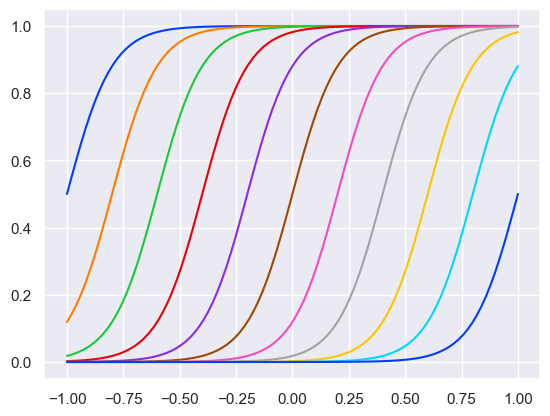

In [24]:
x = np.linspace(-1, 1, 100)
n = 11

sigmoidal = create_sigmoidal(np.linspace(-1, 1, 11), 0.1)

for i in range(n):
    y = list(map(lambda x: sigmoidal(x, i), x))
    plt.plot(x, y, '-')

### 1.4) Optimization of Error function

write the `optimial_weights` function that takes `basis` function (linear function that takes `x` (scalar) and `i` (index)), `inputs` (list Nx1), `targets` (list Nx1), and `M` (scalar number of weights) as parameters and returns optimal weights (list|ndarray (M+1)x1) for this data and basis function. The ouput weights from this function should correspond to the output of the last equation given in slide 11 of lecture 11.

In [29]:
def optimial_weights(basis, inputs, targets, M):
    N = len(inputs)
    X_T = np.array([[(1 if i == 0 else basis(inputs[q], i)) for q in range(N)] for i in range(M)])
    #print(np.size(X,0),np.size(X,1))
    X = np.transpose(X_T)
    #print(X)
    weights = np.linalg.inv(X_T @ X) @ X_T @ np.array(targets)

    return weights

### 1.5) Test models

In [39]:
def test(basis, M, label=''):
    weights = optimial_weights(basis, x_train, y_train, M)
    plt.plot(x_test, list(map(lambda x: linear(x, basis, weights), x_test)), '-', label=label)
    plt.plot(x_train, y_train, 'og')
    plt.legend()

The following code will test the performance of the optimal model using different basis function on input data generated at the start of the notebook. Which model you believe performs the best on this data? Does the model size affect the model performance?

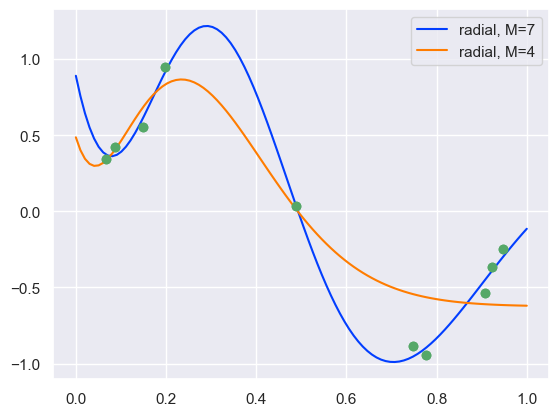

In [40]:
test(create_radial(np.linspace(-1, 1, 10), 0.1), 7, 'radial, M=7')
test(create_radial(np.linspace(-1, 1, 10), 0.1), 4, 'radial, M=4')

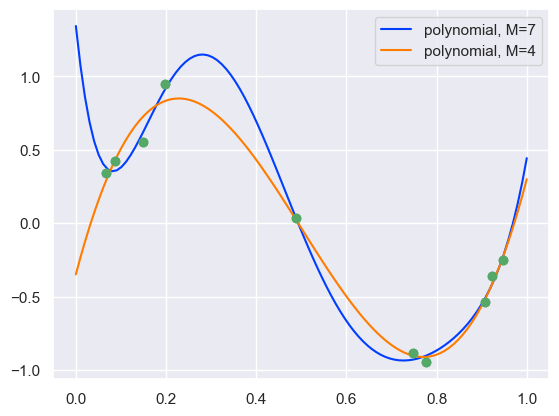

In [41]:
test(create_polynomial(), 7, 'polynomial, M=7')
test(create_polynomial(), 4, 'polynomial, M=4')

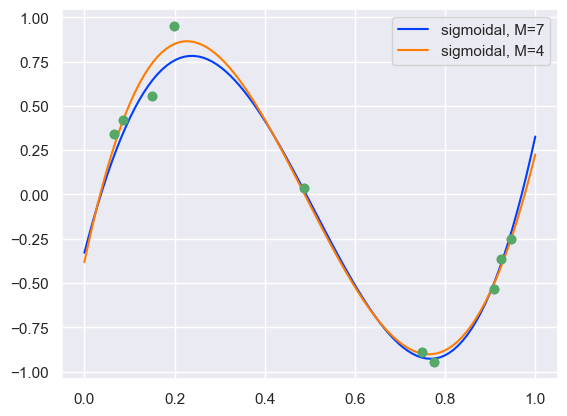

In [42]:
test(create_sigmoidal(np.linspace(0, 1, 8), 1), 7, 'sigmoidal, M=7')
test(create_sigmoidal(np.linspace(0, 1, 8), 1), 4, 'sigmoidal, M=4')

## 2) Bayesian Linear Regression

### 2.1) Generate data

The following functions generate training and test data corresponding to a linear function. The data corresponds to a regression problem where individual input `x` and output `y` are both scalars

In [33]:
def line_func(x): return -0.5 + 0.3 * x

def generate_line_data(size):
    rng = np.random.RandomState(26052605)
    x_train = rng.uniform(0., 1., size)
    y_train = line_func(x_train) + rng.normal(scale=0.05, size=size)
    x_test = np.linspace(0., 1., 100)
    y_test = line_func(x_test)

    return x_train, y_train, x_test, y_test

xl_train, yl_train, xl_test, yl_test = generate_line_data(25)

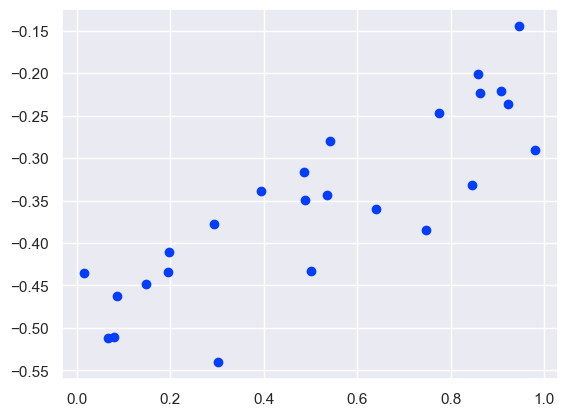

In [34]:
plt.scatter(xl_train, yl_train)

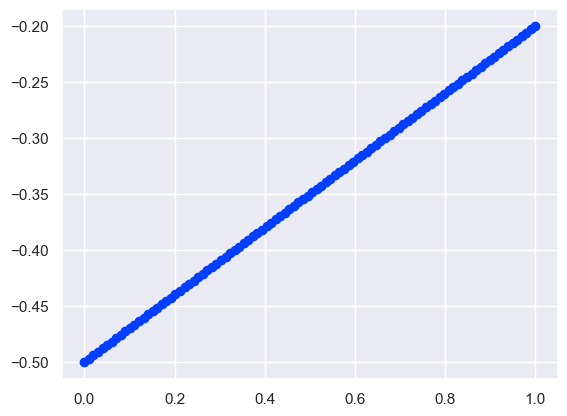

In [35]:
plt.scatter(xl_test, yl_test)

### 2.2) Fit the data

write the `bayessian_regression_fit` function that takes `PHI` (ndarray Nx(M+1)), `t` (ndarray Nx1 targets), `alpha` (scalar) and `beta` (scalar) as parameters and must return `mean` (ndarray Mx1) , and `covariance` (ndarray MxM) for the weight vector using a Bayesian approach (see slide 14 in lecture 12)

In [36]:
def bayessian_regression_fit(PHI, t, alpha, beta):
    ndim = np.size(PHI, 1)
    mean_prev = np.zeros(ndim)
    precision_prev = alpha * np.eye(ndim)

    w_precision = precision_prev + beta * PHI.T @ PHI
    
    w_mean = np.linalg.solve(
        w_precision, beta * PHI.T @ t
        )

    w_cov = np.linalg.inv(w_precision)

    return w_mean, w_cov

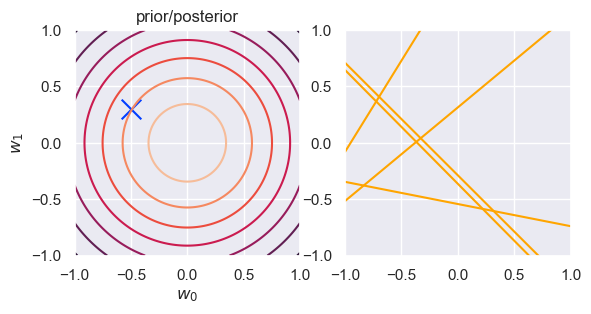

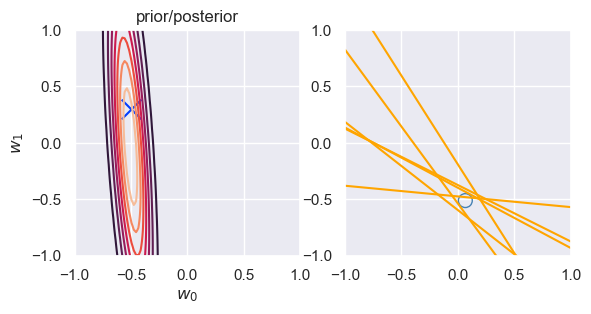

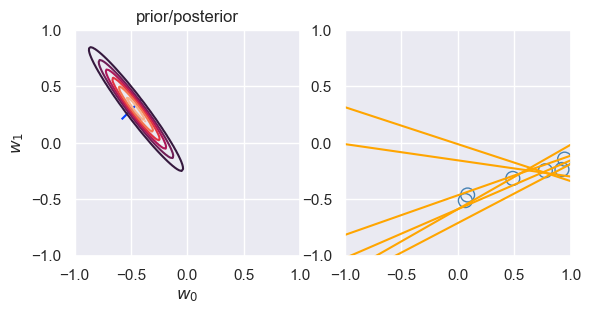

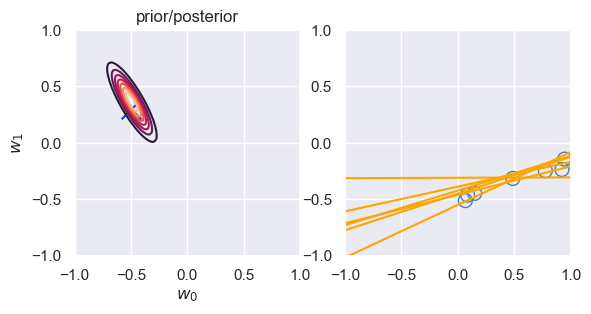

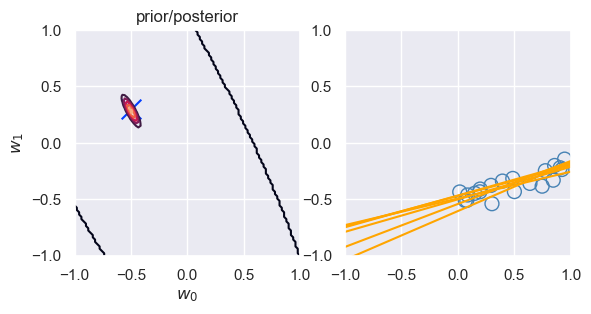

In [37]:
alpha = 1
beta = 100

x = np.linspace(-1, 1, 100)
w0, w1 = np.meshgrid(
    np.linspace(-1, 1, 100),
    np.linspace(-1, 1, 100)
)
w = np.array([w0, w1]).transpose(1, 2, 0)

basis = create_polynomial()

M = 1

PHI = np.array([[basis(x[q], i) for q in range(len(x))] for i in range(M + 1)]).T
PHI_train = np.array([[basis(xl_train[q], i) for q in range(len(xl_train))] for i in range(M + 1)]).T

for begin, end in [[0, 0], [0, 1], [3, 6], [4, 7], [3, 20]]:

    w_mean, w_cov = bayessian_regression_fit(PHI_train[begin:end], yl_train[begin:end], alpha, beta)

    w_sample = np.random.multivariate_normal(
        w_mean.reshape(-1), w_cov, size=6
    )
    y_sample = PHI @ w_sample.T


    plt.subplot(1, 2, 1)
    plt.scatter(-0.5, 0.3, s=200, marker="x")
    plt.contour(w0, w1, multivariate_normal.pdf(w, mean=w_mean, cov=w_cov))
    plt.gca().set_aspect('equal')
    plt.xlabel("$w_0$")
    plt.ylabel("$w_1$")
    plt.title("prior/posterior")

    plt.subplot(1, 2, 2)
    plt.scatter(xl_train[:end], yl_train[:end], s=100, facecolor="none", edgecolor="steelblue", lw=1)
    plt.plot(x, y_sample, c="orange")
    plt.xlim(-1, 1)
    plt.ylim(-1, 1)
    plt.gca().set_aspect('equal', adjustable='box')
    plt.show()

### 2.3) Predictive distribution

write the `sample` function which takes `PHI_train` (ndarray Nx(M+1)), `y_train` (ndarray Nx1), `alpha` (scalar), `beta` (scalar), and `PHI_test` as parameters and returns `y` (ndarray N_test x 1 prediction means) and `y_std` (ndarray N_test x 1 prediction standard deviations). See slide 16 in lecture 12 for more details on how to implement the function.

In [63]:
def sample(PHI_train, y_train, alpha, beta, PHI_test):
    w_mean, w_cov = bayessian_regression_fit(PHI_train, y_train, alpha, beta)

    y = PHI_test @ w_mean   #Phi*m ????

    y_std = np.zeros_like(y) ##########################
    for i in range(np.size(PHI_test,0)): ###############3
      y_std[i] = np.sqrt((1 / beta) + ((PHI_test[i,:]@w_cov)@(PHI_test[i,:].T))) ##############################33

    return y, y_std

100 9


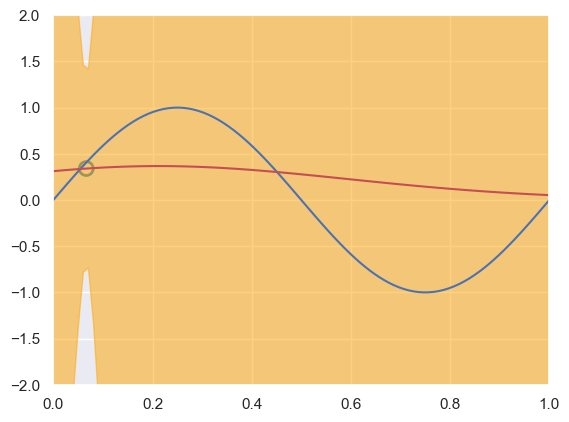

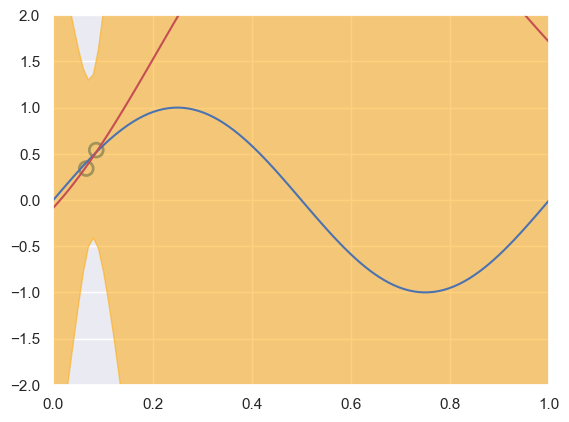

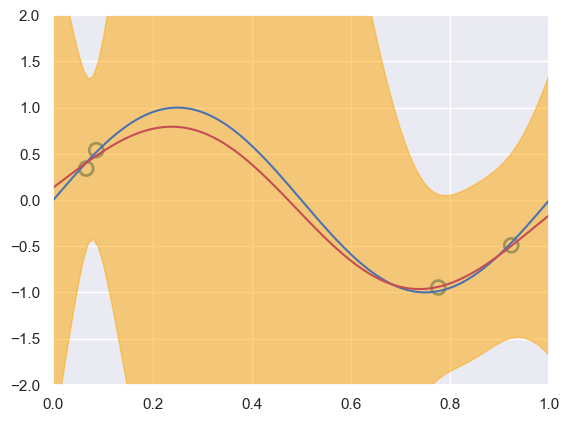

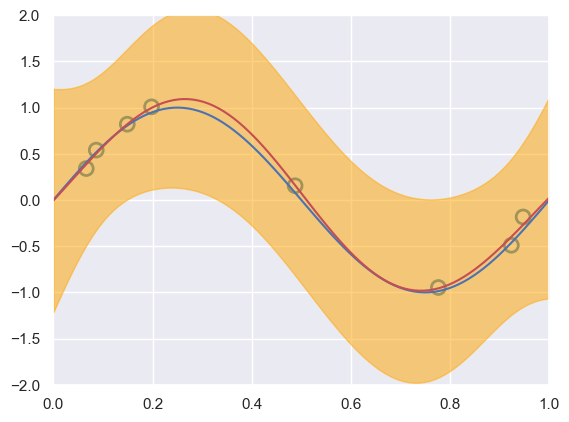

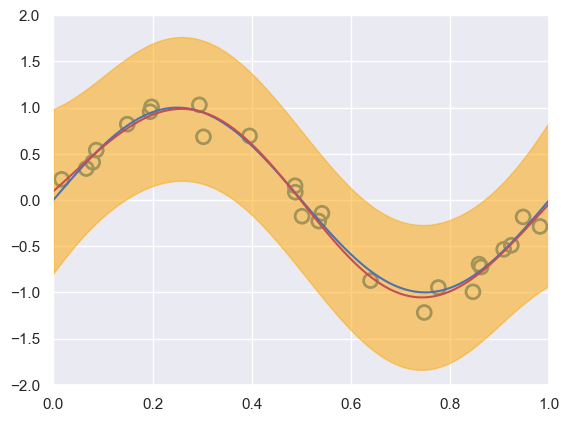

In [68]:
alpha = 1e-3
beta = 2
x_train, y_train, x_test, y_test = generate_data(25)

basis = create_radial(np.linspace(0, 1, 9), 0.1)
#basis = create_polynomial()

M = 8

PHI_train = np.array([[basis(x_train[q], i) for q in range(len(x_train))] for i in range(M + 1)]).T
PHI_test = np.array([[basis(x_test[q], i) for q in range(len(x_test))] for i in range(M + 1)]).T
print(np.size(PHI_test,0),np.size(PHI_test,1))

for begin, end in [[0, 1], [1, 2], [2, 4], [4, 8], [8, 25]]:

    y, y_std = sample(PHI_train[:end], y_train[:end], alpha, beta, PHI_test) ##########################
    plt.scatter(x_train[:end], y_train[:end], s=100, facecolor="none", edgecolor="steelblue", lw=2)
    plt.plot(x_test, y_test,'b')
    plt.plot(x_test, y,'r')
    plt.fill_between(x_test, y - y_std, y + y_std, color="orange", alpha=0.5)
    plt.xlim(0, 1)
    plt.ylim(-2, 2)
    plt.show()